<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U3-T2-V1.2-Recomendação hibrida</b></h2>


---

# Exemplo 01 - Recomendação híbrida monolítica

In [50]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [51]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

## Carregar os arquivos

### Carregar o arquivo de filmes

In [52]:
movies = pd.read_csv('https://drive.google.com/uc?export=download&id=1yjGdaAJ5-YgIUx_1mLTcPqiZ8OI9TeqH', encoding='latin-1', low_memory=False)
movies['tags'] = movies['tags'].apply(lambda x: '' if isinstance(x,float) else x)
movies.set_index('movieId', inplace=True)
movies.head()

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,2,215,3.920930,3.894473
2,Jumanji,Adventure|Children|Fantasy,fantasy magic_board_game game robin_williams,4,110,3.431818,3.419009
3,Grumpier Old Men,Comedy|Romance,old moldy,2,52,3.259615,3.260033
4,Waiting to Exhale,Comedy|Drama|Romance,,0,7,2.357143,2.866377
5,Father of the Bride Part II,Comedy,pregnancy remake,2,49,3.071429,3.101070


### Carregar o arquivo de avaliações

In [53]:
ratings = pd.read_csv('https://drive.google.com/uc?export=download&id=1yCT7ximzeYFYHWAbJz3DO8_GL5raID74', encoding='latin-1', low_memory=False)
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [54]:
    MAX_RATING = ratings['rating'].max()
    MAX_RATING

5.0

## Criar função para popularidade

Criar a função **`get_popularity_scores()`** para retornar um score de popopularidade do filme

In [55]:
def get_popularity_scores():
    # normalizar o score entre 0 e 1
    return movies['imdb_score'] / MAX_RATING

get_popularity_scores()

,imdb_score
movieId,
1,0.778895
2,0.683802
3,0.652007
4,0.573275
5,0.620214
...,...
193581,0.667241
193583,0.657241
193585,0.657241


## Criar função para exibir as recomendações

In [56]:
from sklearn.preprocessing import MinMaxScaler

def show_recommendations(scores, user=None, movie=None, topN=10, popularity=False):

    watched_movies = []
    if user is not None:
        watched_movies = list(ratings.query('userId == ' + str(user))['movieId'].values)
        if movie is not None:
            watched_movies.append(movie)

    aux = movies[ ~movies.index.isin(watched_movies) ].copy()
    aux = aux.drop(['tags','tag_count','vote_count','vote_average'], axis=1)
    aux['score'] = scores

    if not popularity:
        return aux.sort_values(by=['score','imdb_score'], ascending=False).head(topN)
    else:
        aux['order'] = aux['score'] * aux['imdb_score']
        return aux.drop(colunas,axis=1).sort_values(by=['order'], ascending=False).head(topN)


show_recommendations(get_popularity_scores())

,title,genres,imdb_score,score
movieId,,,,
318,"Shawshank Redemption, The",Crime|Drama,4.396816,0.879363
858,"Godfather, The",Crime|Drama,4.243095,0.848619
2959,Fight Club,Action|Crime|Drama|Thriller,4.232872,0.846574
260,Star Wars: Episode IV - A New Hope,Action|Adventure|Sci-Fi,4.197546,0.839509
50,"Usual Suspects, The",Crime|Mystery|Thriller,4.196535,0.839307
1221,"Godfather: Part II, The",Crime|Drama,4.194652,0.838930
527,Schindler's List,Drama|War,4.187170,0.837434
1213,Goodfellas,Crime|Drama,4.184163,0.836833
58559,"Dark Knight, The",Action|Crime|Drama|IMAX,4.182671,0.836534


## Criar o ***user profile***

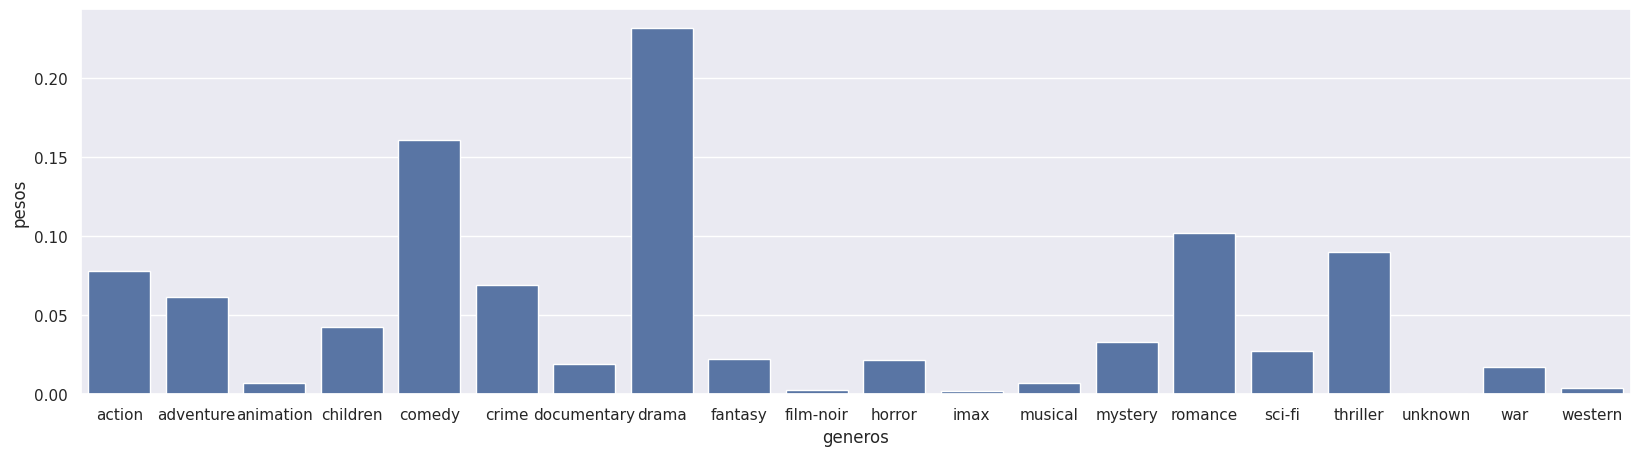

In [57]:
def transf(genre):
    return genre.lower().replace('(no genres listed)','unknown')

all_genres = [s.split("|") for s in movies[movies.genres.notnull()].genres]
unique_genres = sorted(set([transf(item) for l in all_genres for item in l ]))

movie_genres = movies.copy(deep=True)
movie_genres['genres'] = movie_genres.genres.str.split('|')
for g in unique_genres:
    movie_genres[g] = np.zeros(len(movie_genres))

for i, row in movie_genres.iterrows():
    for genre in row['genres']:
        movie_genres.at[i, transf(genre)] = 1

movie_genres.drop(['title','genres', 'tags', 'imdb_score','tag_count', 'vote_count', 'vote_average'], axis=1, inplace=True)

def create_user_profile(user=None, user_ratings=None, movie_genres=movie_genres):
    if ((user is None) & (user_ratings is None)) | ((user is not None) & (user_ratings is not None)):
        raise Exception('Necessário informar um usuário ou classificações')
    if user is not None:
        user_ratings = ratings[ ratings['userId'] == user ][['movieId', 'rating']]

    # Valida se todas as classificações são de filmes válidos
    user_ratings = user_ratings[ user_ratings.index.isin(movie_genres.index) ]

    # Calcular o peso de cada gênero para o usuário ou user_ratings
    userdf = movie_genres[ movie_genres.index.isin(user_ratings.index) ].copy()
    up = userdf.T.dot(user_ratings.rating) /  sum(userdf.T.dot(user_ratings.rating))
    return up

import seaborn as sns

def plot_user_profile(user_profile):
    genres = pd.DataFrame(zip(list(user_profile), sorted(user_profile.keys())), columns=['pesos', 'generos'])
    sns.set(rc={'figure.figsize':(20,5)})
    ax = sns.barplot(x="generos", y="pesos", data=genres)

plot_user_profile(create_user_profile(user=1))

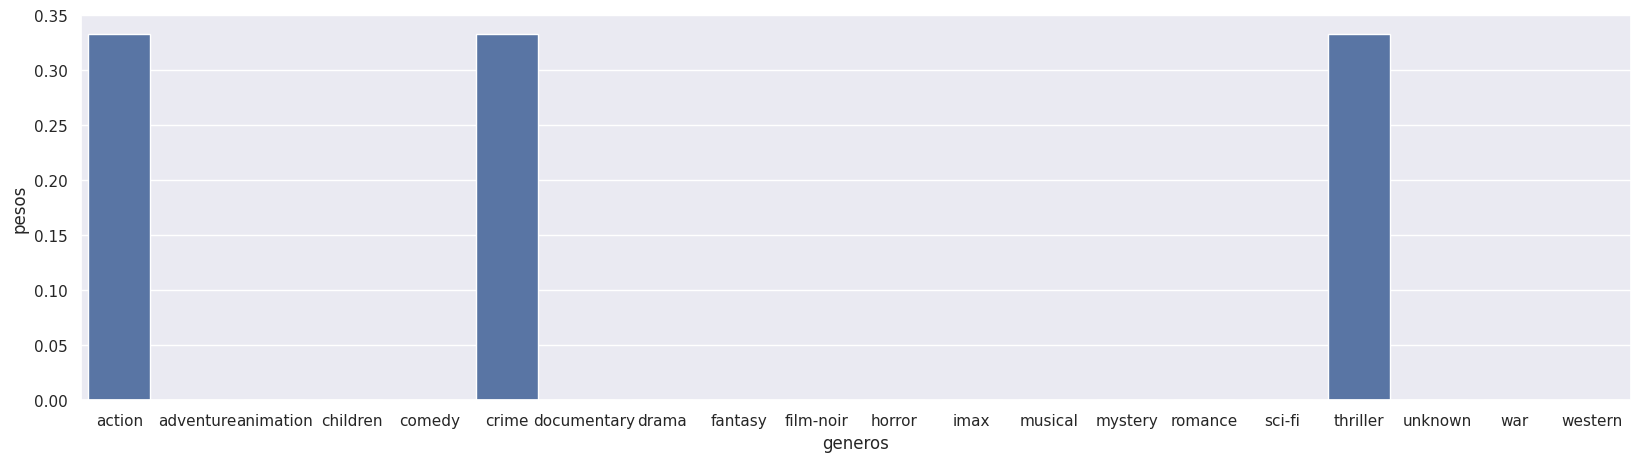

In [58]:
plot_user_profile(create_user_profile(user=405))

### Criar função para o ***user profile***

Criar a função **`get_user_profile_scores()`** para calcular o score de cada filme de duas formas: computando o produto escalar e a similaridade do cosseno

In [59]:
def get_user_profile_scores(user):
    user_profile = create_user_profile(user=user)
    sims = cosine_similarity(movie_genres.values, [user_profile.T.values])
    ups = pd.Series(sims.reshape(-1), index=movie_genres.index)
    return ups

get_user_profile_scores(user=1)

,0
movieId,
1,0.383300
2,0.212201
3,0.540532
4,0.830971
5,0.467922
...,...
193581,0.390707
193583,0.320085
193585,0.674858


In [60]:
show_recommendations(get_user_profile_scores(user=1))

,title,genres,imdb_score,score
movieId,,,,
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,3.571836,0.859943
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,3.728342,0.850166
144606,Confessions of a Dangerous Mind,Comedy|Crime|Drama|Romance|Thriller,3.336203,0.850166
3893,Nurse Betty,Comedy|Crime|Drama|Romance|Thriller,3.316501,0.850166
496,What Happened Was...,Comedy|Drama|Romance|Thriller,3.436203,0.850136
5666,"Rules of Attraction, The",Comedy|Drama|Romance|Thriller,3.383002,0.850136
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,3.436203,0.833148
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.830971
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.830971


In [61]:
show_recommendations(get_user_profile_scores(user=405))

,title,genres,imdb_score,score
movieId,,,,
6874,Kill Bill: Vol. 1,Action|Crime|Thriller,3.916872,1.0
6,Heat,Action|Crime|Thriller,3.890649,1.0
1036,Die Hard,Action|Crime|Thriller,3.827026,1.0
171763,Baby Driver,Action|Crime|Thriller,3.797891,1.0
1953,"French Connection, The",Action|Crime|Thriller,3.757542,1.0
8665,"Bourne Supremacy, The",Action|Crime|Thriller,3.730500,1.0
54286,"Bourne Ultimatum, The",Action|Crime|Thriller,3.654023,1.0
168248,John Wick: Chapter Two,Action|Crime|Thriller,3.647627,1.0
4855,Dirty Harry,Action|Crime|Thriller,3.615932,1.0


## Recomendação baseada em conteúdo

### Criar função de recomendação baseada em conteúdo

Função para retornar o score de recomendação baseada em conteúdo




In [62]:
def get_content_scores(user=None, topN=None):

    up_scores = get_user_profile_scores(user=user)

    aux = pd.DataFrame(up_scores, columns=['user_profile_score'])
    aux['score'] = up_scores
    if topN is not None:
        return aux.sort_values(by=['score'], ascending=False)['score'].head(topN)
    else:
        return aux['score']

get_content_scores(user=1, topN=5)

,score
movieId,
4956,0.859943
1912,0.850166
3893,0.850166
144606,0.850166
5666,0.850136


In [63]:
show_recommendations(get_content_scores(user=1))

,title,genres,imdb_score,score
movieId,,,,
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,3.571836,0.859943
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,3.728342,0.850166
144606,Confessions of a Dangerous Mind,Comedy|Crime|Drama|Romance|Thriller,3.336203,0.850166
3893,Nurse Betty,Comedy|Crime|Drama|Romance|Thriller,3.316501,0.850166
496,What Happened Was...,Comedy|Drama|Romance|Thriller,3.436203,0.850136
5666,"Rules of Attraction, The",Comedy|Drama|Romance|Thriller,3.383002,0.850136
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,3.436203,0.833148
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.830971
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.830971


##  Recomendação colaborativa

### Preparar arquivos para a ***LibRecommender***

In [64]:
!pip install -q LibRecommender

In [65]:
from libreco.data import DatasetPure
from libreco.algorithms import SVD, SVDpp, ItemCF, UserCF, LightGCN
from libreco.evaluation import evaluate
import tensorflow as tf


In [66]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [67]:
libdata = ratings[['userId', 'movieId', 'rating']].\
    rename(columns={"userId":"user", "movieId":"item", "rating": "label"})


In [68]:
train_data, data_info = DatasetPure.build_trainset(libdata)
test_data = DatasetPure.build_testset(libdata)

### Treinar o modelo colaborativo

In [69]:
from libreco.algorithms import SVD

tf.compat.v1.reset_default_graph()

svd = SVD(task="rating", data_info=data_info)
svd.fit(train_data, neg_sampling=False, verbose=0, metrics=["rmse"])

result = evaluate(model=svd, data=test_data, neg_sampling=False, metrics=["rmse"])
print(result)

Training start time: 2026-02-18 15:02:28


eval_pointwise: 100%|██████████| 13/13 [00:00<00:00, 560.15it/s]

{'rmse': np.float64(0.6328733546594254)}


In [70]:
svd.predict(user=1, item=1)

array([4.4340086], dtype=float32)

In [71]:
svd.predict(user=1, item=15)

array([4.032356], dtype=float32)

In [72]:
svd.recommend_user(user=1, n_rec=10)

{np.int64(1): array([136850,  51931,    391,  26116, 130482,  81535,   5607,  68536,
          3942,    876])}

### Criar função de recomendação colaborativa

In [73]:
def get_collaborative_scores(user=None, topN=None):

    aux = movies[['title','genres','imdb_score']]
    # Calcula a avaliação estimada usando a recomendação colaborativa
    aux = aux.reset_index()
    aux['score'] = aux['movieId'].apply(lambda x: svd.predict(user, x)[0] / MAX_RATING)
    aux = aux.set_index('movieId')

    if topN is not None:
        return aux.sort_values(by=['score','imdb_score'], ascending=False)['score'].head(topN)
    else:
        return aux['score']

get_collaborative_scores(user=1, topN=5)

,score
movieId,
318,1.0
858,1.0
1221,1.0
1213,1.0
750,1.0


In [74]:
show_recommendations(get_collaborative_scores(user=1))

,title,genres,imdb_score,score
movieId,,,,
318,"Shawshank Redemption, The",Crime|Drama,4.396816,1.0
858,"Godfather, The",Crime|Drama,4.243095,1.0
1221,"Godfather: Part II, The",Crime|Drama,4.194652,1.0
1213,Goodfellas,Crime|Drama,4.184163,1.0
750,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War,4.182661,1.0
48516,"Departed, The",Crime|Drama|Thriller,4.175535,1.0
1197,"Princess Bride, The",Action|Adventure|Comedy|Fantasy|Romance,4.174583,1.0
904,Rear Window,Mystery|Thriller,4.165183,1.0
912,Casablanca,Drama|Romance,4.159285,1.0


## Recomendação híbrida com abordagem **monolítica** - versão 1

Nesta primeira versão do recomendador híbrido monolítico, vamos fazer a seleção dos candidatos usando a **recomendação baseada em conteúdo** e depois estimar a predição de forma **colaborativa**.

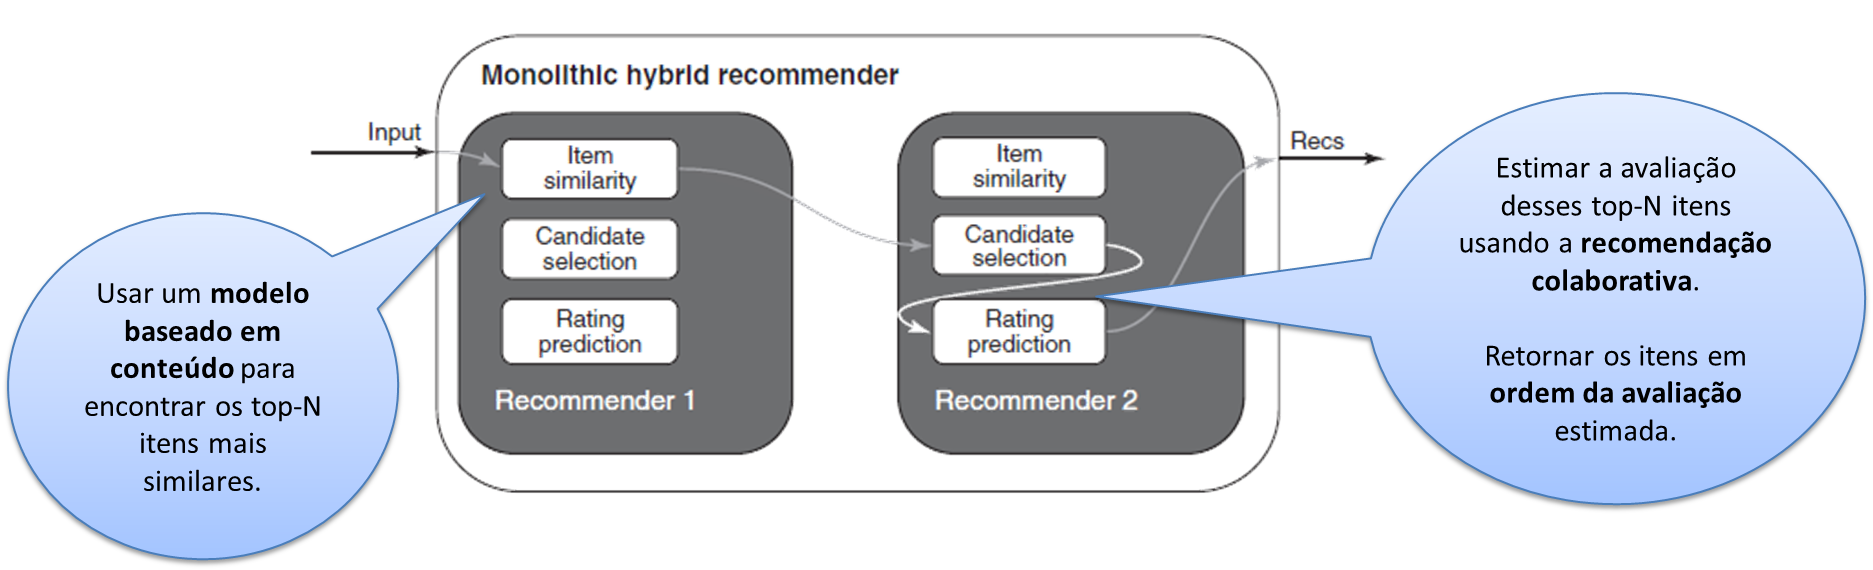

#### Criar a função **`get_monolithic_hybrid_recommendation()`**

In [75]:
def get_monolithic_hybrid_recommendation(user=None, topN=10, subset=20):

    # Recupera filmes já vistos pelo usuário
    watched_movies = list(ratings.query('userId == ' + str(user))['movieId'].values)

    # Seleciona o subset de filmes por recomendação baseada em conteúdo
    content_scores = get_content_scores(user=user, topN=subset)
    aux = movies.loc[content_scores.index][['title','genres','tags','imdb_score']]

    # Calcula a avaliação estimada usando a recomendação colaborativa
    aux = aux.reset_index()
    aux['score'] = aux['movieId'].apply(lambda x: svd.predict(user, x)[0] / MAX_RATING)
    aux = aux.set_index('movieId')

    aux = aux[ ~aux.index.isin(watched_movies) ]

    return aux.sort_values(by=['score','imdb_score'], ascending=False).head(topN)

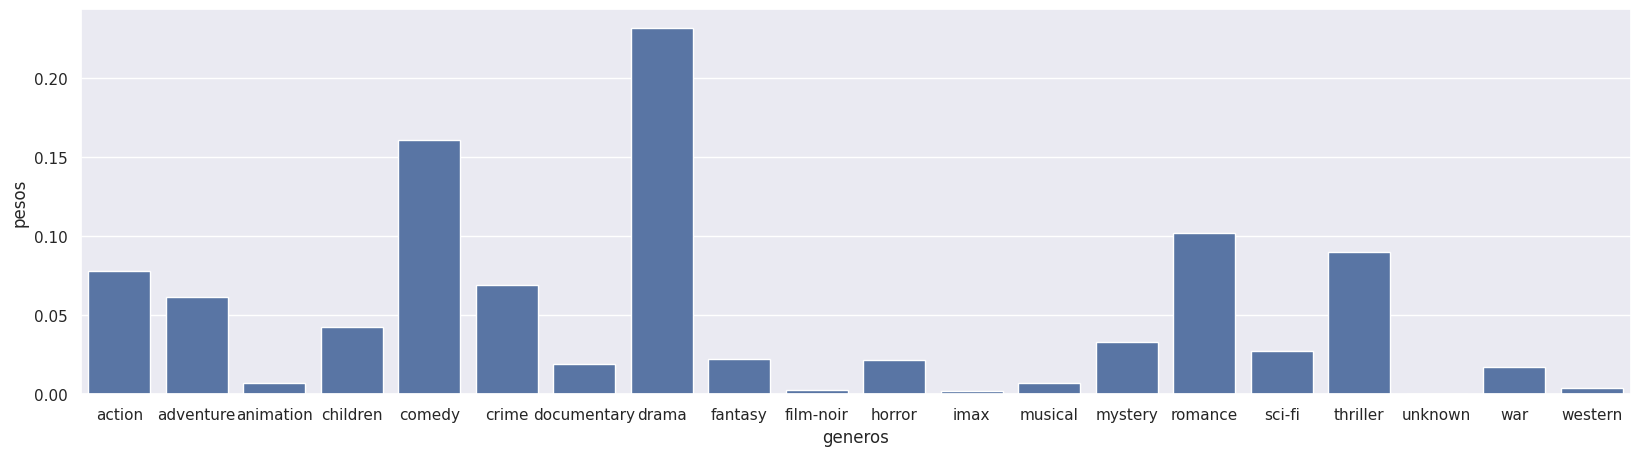

In [76]:
plot_user_profile(create_user_profile(user=1))

In [77]:
get_monolithic_hybrid_recommendation(user=1)

,title,genres,tags,imdb_score,score
movieId,,,,,
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,heist,3.728342,1.000000
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,,3.571836,1.000000
496,What Happened Was...,Comedy|Drama|Romance|Thriller,,3.436203,1.000000
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,,3.436203,1.000000
66665,Away We Go,Comedy|Drama|Romance,,3.335541,1.000000
5666,"Rules of Attraction, The",Comedy|Drama|Romance|Thriller,,3.383002,0.907070
3893,Nurse Betty,Comedy|Crime|Drama|Romance|Thriller,,3.316501,0.881818
27808,Spanglish,Comedy|Drama|Romance,adam_sandler family sweet,3.318102,0.876039
144606,Confessions of a Dangerous Mind,Comedy|Crime|Drama|Romance|Thriller,,3.336203,0.867001


In [78]:
get_monolithic_hybrid_recommendation(user=1, subset=100)

,title,genres,tags,imdb_score,score
movieId,,,,,
1235,Harold and Maude,Comedy|Drama|Romance,may-december_romance,4.024630,1.0
58,"Postman, The (Postino, Il)",Comedy|Drama|Romance,writing,3.877436,1.0
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,heist,3.728342,1.0
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,,3.571836,1.0
4741,Together (Tillsammans),Comedy|Drama|Romance,,3.460127,1.0
48744,Shortbus,Comedy|Drama|Romance,,3.446836,1.0
496,What Happened Was...,Comedy|Drama|Romance|Thriller,,3.436203,1.0
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,,3.436203,1.0
67618,Strictly Sexual,Comedy|Drama|Romance,,3.436203,1.0


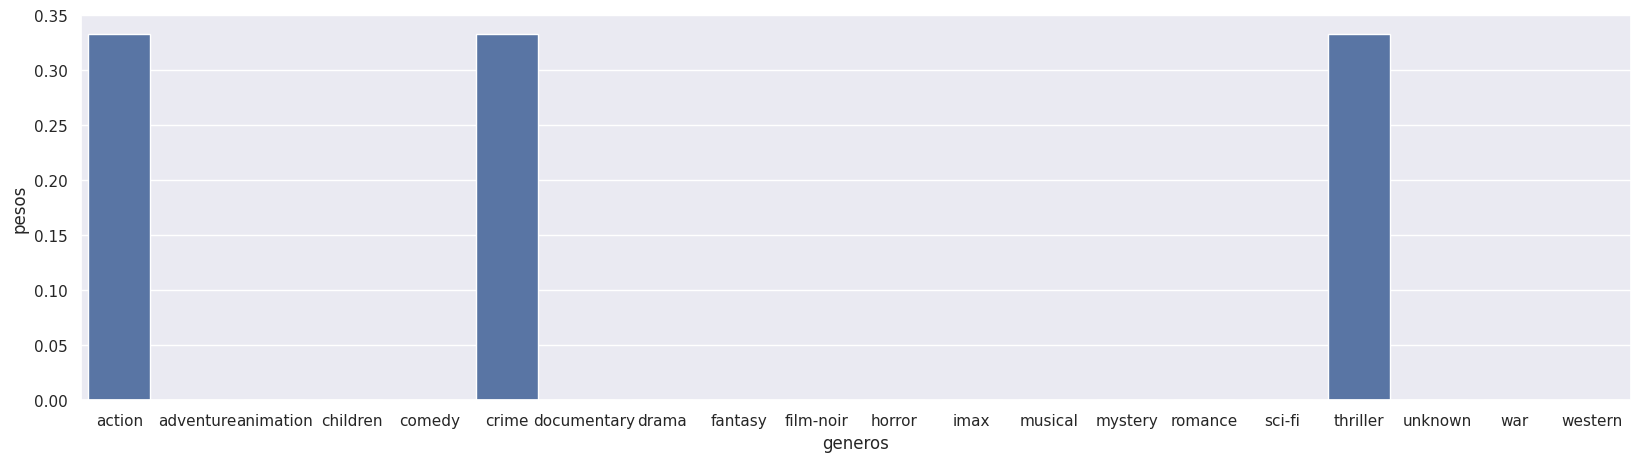

In [79]:
plot_user_profile(create_user_profile(user=405))

In [80]:
get_monolithic_hybrid_recommendation(user=405)

,title,genres,tags,imdb_score,score
movieId,,,,,
171763,Baby Driver,Action|Crime|Thriller,,3.797891,0.905225
86892,The Man from Nowhere,Action|Crime|Thriller,,3.571836,0.831894
4855,Dirty Harry,Action|Crime|Thriller,,3.615932,0.827680
6,Heat,Action|Crime|Thriller,,3.890649,0.776896
1036,Die Hard,Action|Crime|Thriller,,3.827026,0.774171
105585,Machete Kills (Machete 2),Action|Crime|Thriller,,3.396549,0.770341
90600,Headhunters (Hodejegerne),Action|Crime|Thriller,,3.383002,0.737162
4351,Point Break,Action|Crime|Thriller,,3.254481,0.708684
99112,Jack Reacher,Action|Crime|Thriller,,3.350573,0.701720


## Recomendação híbrida com abordagem **monolítica** - versão 2

Agora, nesta segunda versão do recomendador híbrido monolítico, vamos fazer a seleção dos candidatos usando a **recomendação baseada em filtragem colaborativa** e depois estimar a avaliação usando a abordagem baseada em **conteúdo**.

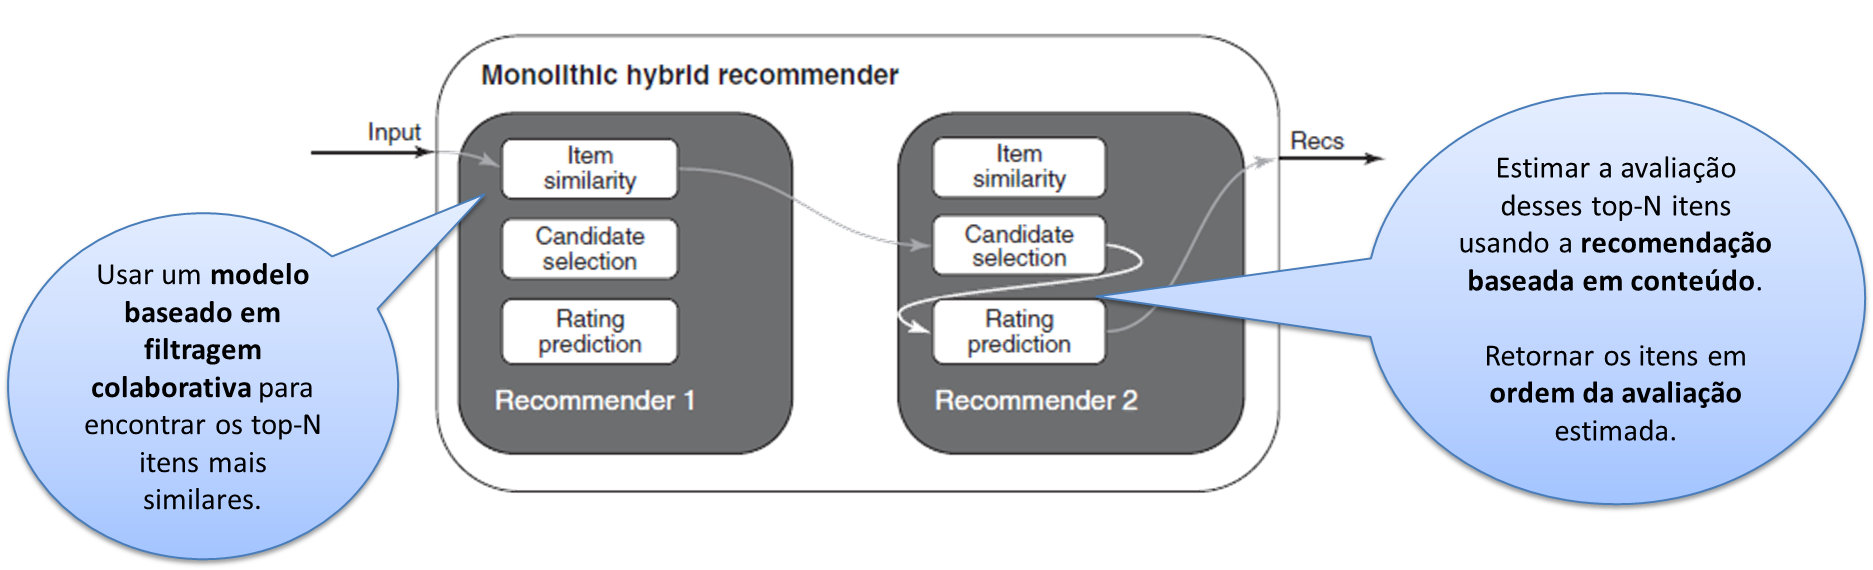

#### Criar a função **`get_monolithic_hybrid_recommendation2()`**

In [81]:
def get_monolithic_hybrid_recommendation2(user=None, topN=10, subset=20):

    # Recupera filmes já vistos pelo usuário
    watched_movies = list(ratings.query('userId == ' + str(user))['movieId'].values)

    # Seleciona o subset de filmes por recomendação colaborativa
    colaborative_scores = get_collaborative_scores(user=user,topN=subset)
    aux = movies.loc[colaborative_scores.index][['title','genres','tags','imdb_score']]

    # Calcula a avaliação estimada usando a recomendação baseada em conteúdo
    aux = aux.reset_index()
    aux['score'] = aux['movieId'].apply(lambda x: get_content_scores(user=user).loc[x])
    aux = aux.set_index('movieId')

    aux = aux[ ~aux.index.isin(watched_movies) ]

    return aux.sort_values(by=['score','imdb_score'], ascending=False).head(topN)


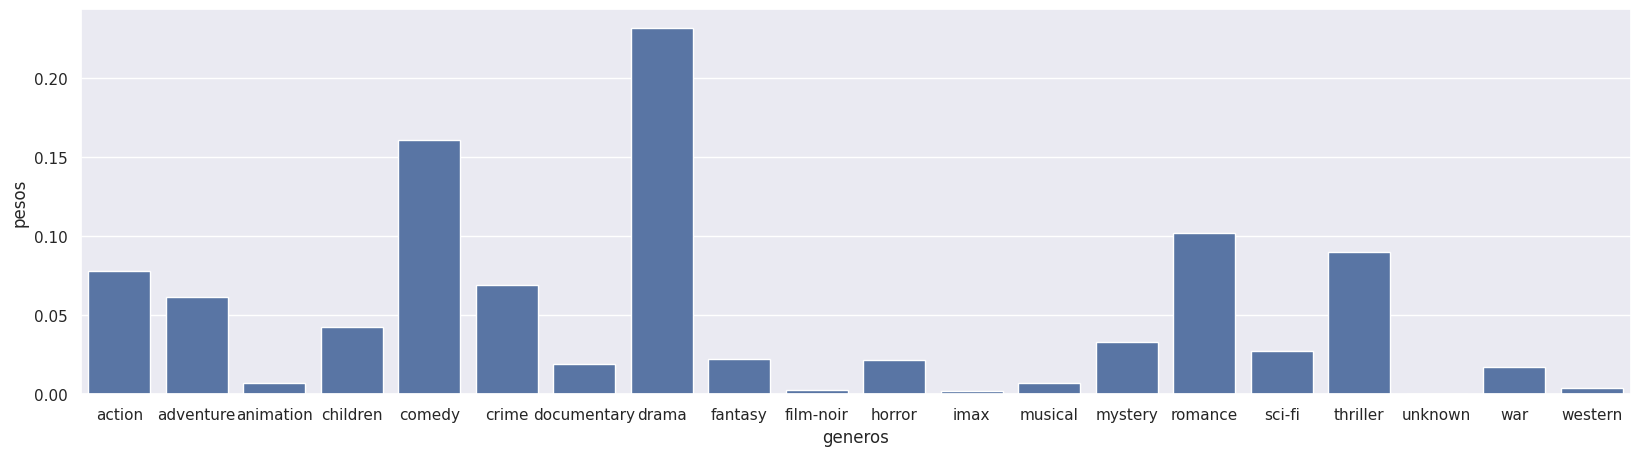

In [82]:
plot_user_profile(create_user_profile(user=1))

In [83]:
get_monolithic_hybrid_recommendation(user=1)

,title,genres,tags,imdb_score,score
movieId,,,,,
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,heist,3.728342,1.000000
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,,3.571836,1.000000
496,What Happened Was...,Comedy|Drama|Romance|Thriller,,3.436203,1.000000
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,,3.436203,1.000000
66665,Away We Go,Comedy|Drama|Romance,,3.335541,1.000000
5666,"Rules of Attraction, The",Comedy|Drama|Romance|Thriller,,3.383002,0.907070
3893,Nurse Betty,Comedy|Crime|Drama|Romance|Thriller,,3.316501,0.881818
27808,Spanglish,Comedy|Drama|Romance,adam_sandler family sweet,3.318102,0.876039
144606,Confessions of a Dangerous Mind,Comedy|Crime|Drama|Romance|Thriller,,3.336203,0.867001


In [84]:
get_monolithic_hybrid_recommendation2(user=1)

,title,genres,tags,imdb_score,score
movieId,,,,,
912,Casablanca,Drama|Romance,start_of_a_beautiful_friendship,4.159285,0.686857
1193,One Flew Over the Cuckoo's Nest,Drama,mental_illness emotional jack_nicholson,4.143395,0.674858
1276,Cool Hand Luke,Drama,prison,4.134273,0.674858
1104,"Streetcar Named Desire, A",Drama,tennessee_williams,4.098691,0.674858
1225,Amadeus,Drama,mozart salieri,4.086612,0.674858
48516,"Departed, The",Crime|Drama|Thriller,martin_scorsese way_too_long undercover_cop le...,4.175535,0.656218
318,"Shawshank Redemption, The",Crime|Drama,prison wrongful_imprisonment morgan_freeman st...,4.396816,0.619154
858,"Godfather, The",Crime|Drama,mafia,4.243095,0.619154
1221,"Godfather: Part II, The",Crime|Drama,al_pacino mafia,4.194652,0.619154


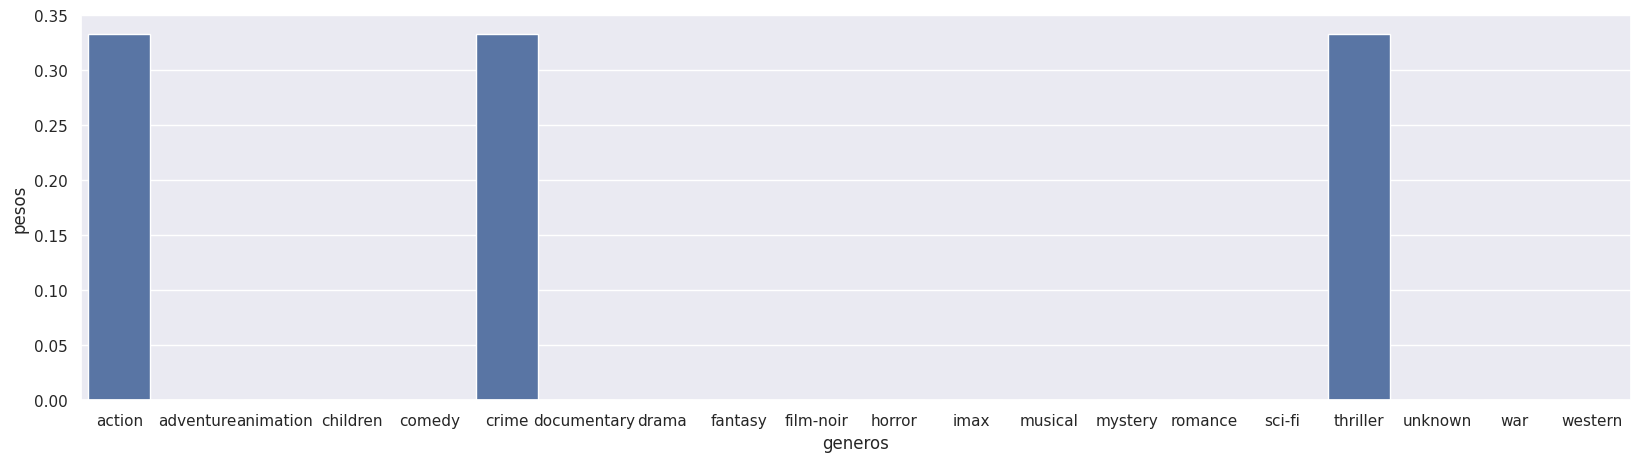

In [85]:
plot_user_profile(create_user_profile(user=405))

In [86]:
get_monolithic_hybrid_recommendation2(user=405)

,title,genres,tags,imdb_score,score
movieId,,,,,
876,Supercop 2 (Project S) (Chao ji ji hua),Action|Comedy|Crime|Thriller,,3.436203,0.866025
4441,Game of Death,Action,,3.488503,0.577350
26116,"Hush... Hush, Sweet Charlotte",Horror|Thriller,,3.487458,0.408248
4789,Phantom of the Paradise,Comedy|Fantasy|Horror|Musical|Thriller,,3.530170,0.258199
7008,Last Tango in Paris (Ultimo tango a Parigi),Drama|Romance,,3.704431,0.000000
2131,Autumn Sonata (HÃ¶stsonaten),Drama,,3.681695,0.000000
3022,"General, The",Comedy|War,,3.631224,0.000000
7842,Dune,Drama|Fantasy|Sci-Fi,,3.604772,0.000000
3473,Jonah Who Will Be 25 in the Year 2000 (Jonas q...,Comedy,,3.578367,0.000000


# Exemplo 02 - Recomendação híbrida com abordagem ***mixed***

## Abordagem ***mixed***

Empilha ou reordena a saída de diferentes sistemas

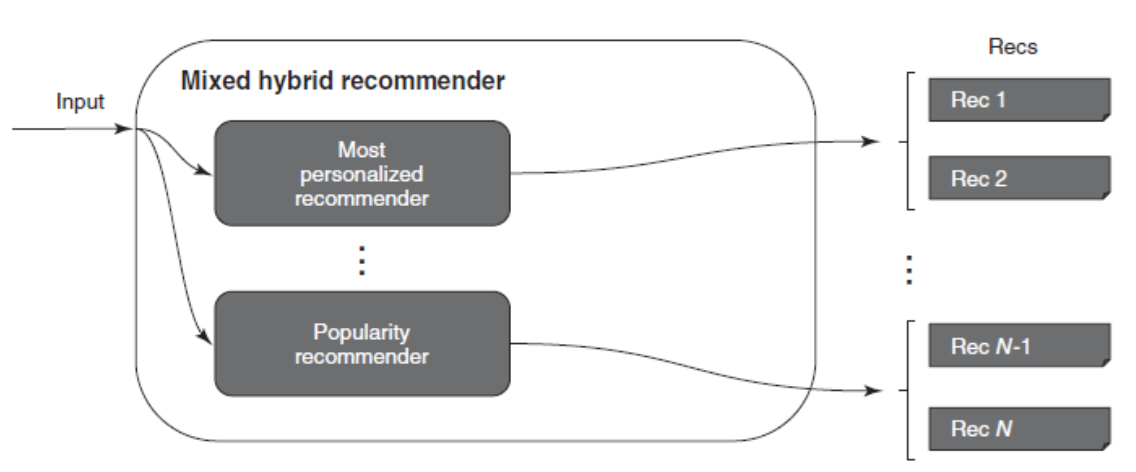

#### Criar a função **`get_mixed_hybrid_recommendation()`**

In [87]:
def get_mixed_hybrid_recommendation(user=None, topN=10):

    # Desconsiderar os filmes que o usuário já assistiu
    watched_movies = list(ratings.query('userId == ' + str(user))['movieId'].values)

    # Calcular o score baseado no imdb
    aux_pop = movies[['title','genres','tags','imdb_score']].copy()
    aux_pop['score'] = (aux_pop['imdb_score'] / MAX_RATING)
    aux_pop.drop(['imdb_score'],axis=1,inplace=True)
    aux_pop['source'] = 'imdb'

    # Calcular o score baseado em conteudo
    aux_cont = movies[['title','genres','tags']].copy()
    content_scores = get_content_scores(user=user)
    aux_cont['score'] = content_scores
    aux_cont['source'] = 'content'

    # Calcular o score baseado em colaboração
    aux_colab = movies[['title','genres','tags']].copy()
    aux_colab = aux_colab.reset_index()
    aux_colab['score'] = aux_colab['movieId'].apply(lambda x: svd.predict(user, x)[0] / MAX_RATING)
    aux_colab = aux_colab.set_index('movieId')
    aux_colab['source'] = 'collaborative'

    aux = pd.concat([aux_pop, aux_cont, aux_colab])

    return aux[['title','genres','score','source']]\
            .sort_values(by=['score'], ascending=False)\
            .drop_duplicates(subset=['title'])\
            .head(topN)



In [88]:
get_mixed_hybrid_recommendation(user=1)

,title,genres,score,source
movieId,,,,
104069,Louis C.K.: Oh My God,Comedy,1.0,collaborative
103624,Fruitvale Station,Drama,1.0,collaborative
103235,"Best Offer, The (Migliore offerta, La)",Thriller,1.0,collaborative
103107,20 Feet from Stardom (Twenty Feet from Stardom),Documentary,1.0,collaborative
102217,Bill Hicks: Revelations,Comedy,1.0,collaborative
102194,Mud,Adventure|Crime|Drama,1.0,collaborative
102084,Justice League: Doom (2012),Action|Animation|Fantasy,1.0,collaborative
100906,Maniac Cop 2,Action|Horror|Thriller,1.0,collaborative
100882,Journey to the West: Conquering the Demons (Da...,Adventure|Comedy|Fantasy|Romance|IMAX,1.0,collaborative


In [89]:
get_mixed_hybrid_recommendation(user=405)

,title,genres,score,source
movieId,,,,
3086,Babes in Toyland,Children|Comedy|Fantasy|Musical,1.0,collaborative
3096,My Man Godfrey,Comedy,1.0,collaborative
4946,"Eye for an Eye, An",Action|Crime|Thriller,1.0,content
5507,xXx,Action|Crime|Thriller,1.0,content
5423,Gangster No. 1,Action|Crime|Thriller,1.0,content
1752,Hard Rain,Action|Crime|Thriller,1.0,content
1792,U.S. Marshals,Action|Crime|Thriller,1.0,content
104339,In a World...,Comedy,1.0,collaborative
3744,Shaft,Action|Crime|Thriller,1.0,content


# Exemplo 03 - Recomendação híbrida com ***ensemble***

## Recomendação híbrida com abordagem ***ensemble***

Vamos combinar os resultados da abordagem baseada em conteúdo com a abordagem colaborativa

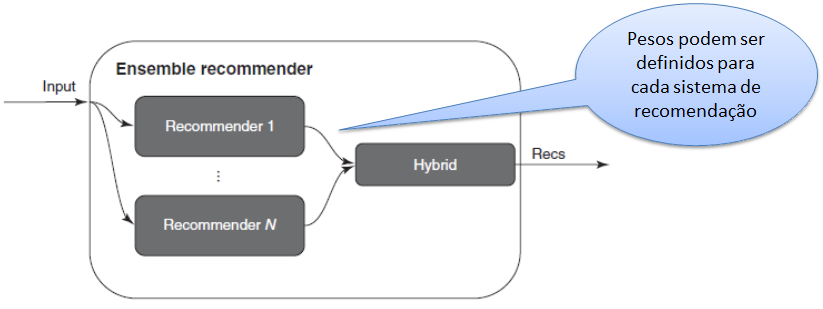

#### Criar a função **`get_ensemble_hybrid_recommendation()`**

In [90]:
def get_ensemble_hybrid_recommendation(user=None, topN=10, weights=[0.5, 0.5]):

    # Desconsiderar os filmes que o usuário já assistiu
    watched_movies = list(ratings.query('userId == ' + str(user))['movieId'].values)

    aux = movies[['title','genres','tags','imdb_score']].copy()
    aux['content_score'] = get_content_scores(user=user)
    aux['collaborative_score'] = get_collaborative_scores(user=user)
    aux['score'] = (weights[0] * aux['content_score']) + (weights[1] * aux['collaborative_score'])

    aux = aux[ ~aux.index.isin(watched_movies) ]
    score_minimo = 0.01
    aux = aux[ (aux['content_score'] > score_minimo) & (aux['collaborative_score'] > score_minimo)]

    return aux[['title','genres','imdb_score','content_score','collaborative_score','score']]\
            .sort_values(by=['score','imdb_score'], ascending=False)\
            .head(topN)

get_ensemble_hybrid_recommendation(user=1)

,title,genres,imdb_score,content_score,collaborative_score,score
movieId,,,,,,
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,3.571836,0.859943,1.0,0.929971
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,3.728342,0.850166,1.0,0.925083
496,What Happened Was...,Comedy|Drama|Romance|Thriller,3.436203,0.850136,1.0,0.925068
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,3.436203,0.833148,1.0,0.916574
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.830971,1.0,0.915486
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.830971,1.0,0.915486
58,"Postman, The (Postino, Il)",Comedy|Drama|Romance,3.877436,0.830971,1.0,0.915486
916,Roman Holiday,Comedy|Drama|Romance,3.853201,0.830971,1.0,0.915486
5902,Adaptation,Comedy|Drama|Romance,3.833855,0.830971,1.0,0.915486


Recomendações híbridas para o usuário

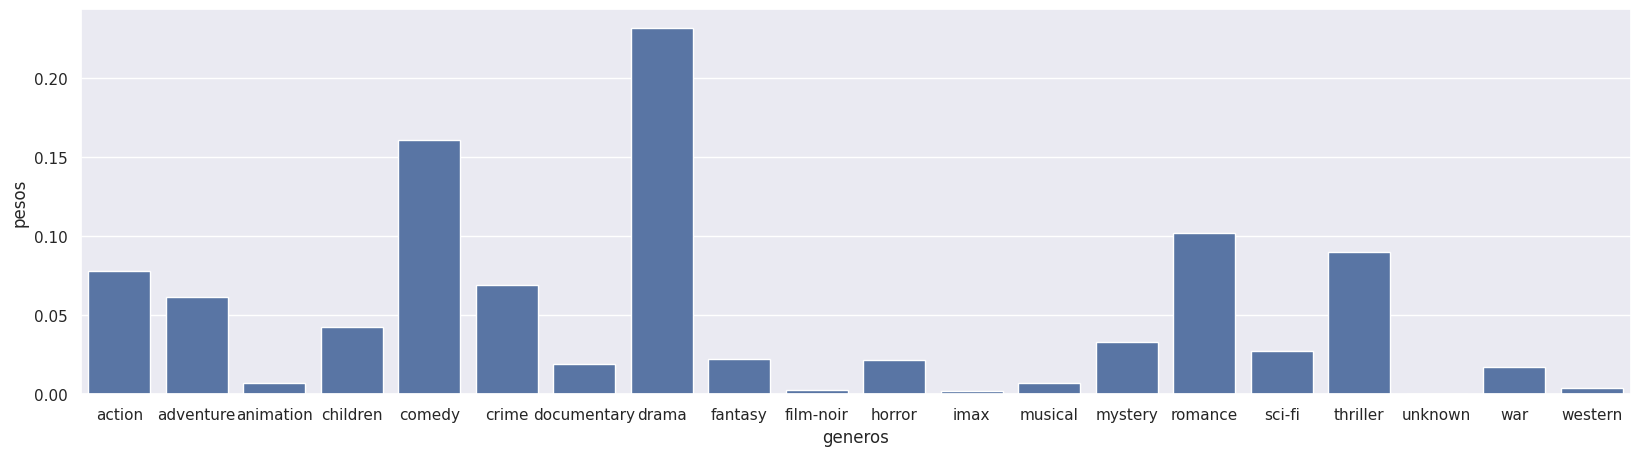

In [91]:
plot_user_profile(create_user_profile(user=1))

In [92]:
get_ensemble_hybrid_recommendation(user=1)

,title,genres,imdb_score,content_score,collaborative_score,score
movieId,,,,,,
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,3.571836,0.859943,1.0,0.929971
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,3.728342,0.850166,1.0,0.925083
496,What Happened Was...,Comedy|Drama|Romance|Thriller,3.436203,0.850136,1.0,0.925068
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,3.436203,0.833148,1.0,0.916574
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.830971,1.0,0.915486
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.830971,1.0,0.915486
58,"Postman, The (Postino, Il)",Comedy|Drama|Romance,3.877436,0.830971,1.0,0.915486
916,Roman Holiday,Comedy|Drama|Romance,3.853201,0.830971,1.0,0.915486
5902,Adaptation,Comedy|Drama|Romance,3.833855,0.830971,1.0,0.915486


Recomendações híbridas com peso maior para o ***user profile***

In [93]:
get_ensemble_hybrid_recommendation(user=1, weights=[0.8, 0.2])

,title,genres,imdb_score,content_score,collaborative_score,score
movieId,,,,,,
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,3.571836,0.859943,1.0,0.887954
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,3.728342,0.850166,1.0,0.880133
496,What Happened Was...,Comedy|Drama|Romance|Thriller,3.436203,0.850136,1.0,0.880108
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,3.436203,0.833148,1.0,0.866519
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.830971,1.0,0.864777
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.830971,1.0,0.864777
58,"Postman, The (Postino, Il)",Comedy|Drama|Romance,3.877436,0.830971,1.0,0.864777
916,Roman Holiday,Comedy|Drama|Romance,3.853201,0.830971,1.0,0.864777
5902,Adaptation,Comedy|Drama|Romance,3.833855,0.830971,1.0,0.864777


Recomendações híbridas com peso maior para a **filtragem colaborativa**

In [94]:
get_ensemble_hybrid_recommendation(user=1, weights=[0.2, 0.8])

,title,genres,imdb_score,content_score,collaborative_score,score
movieId,,,,,,
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,3.571836,0.859943,1.0,0.971989
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,3.728342,0.850166,1.0,0.970033
496,What Happened Was...,Comedy|Drama|Romance|Thriller,3.436203,0.850136,1.0,0.970027
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,3.436203,0.833148,1.0,0.966630
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.830971,1.0,0.966194
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.830971,1.0,0.966194
58,"Postman, The (Postino, Il)",Comedy|Drama|Romance,3.877436,0.830971,1.0,0.966194
916,Roman Holiday,Comedy|Drama|Romance,3.853201,0.830971,1.0,0.966194
5902,Adaptation,Comedy|Drama|Romance,3.833855,0.830971,1.0,0.966194


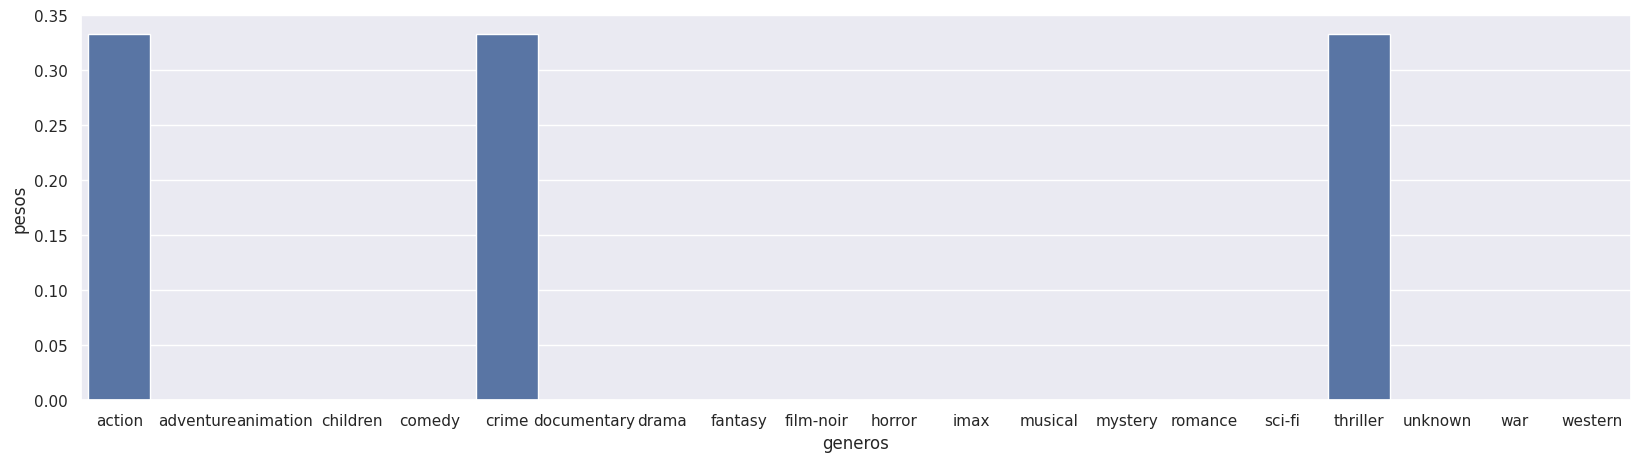

In [95]:
plot_user_profile(create_user_profile(user=405))

In [96]:
get_ensemble_hybrid_recommendation(user=405)

,title,genres,imdb_score,content_score,collaborative_score,score
movieId,,,,,,
168248,John Wick: Chapter Two,Action|Crime|Thriller,3.647627,1.000000,0.944298,0.972149
171763,Baby Driver,Action|Crime|Thriller,3.797891,1.000000,0.905225,0.952613
876,Supercop 2 (Project S) (Chao ji ji hua),Action|Comedy|Crime|Thriller,3.436203,0.866025,1.000000,0.933013
26736,Riki-Oh: The Story of Ricky (Lik Wong),Action|Crime|Thriller,3.386203,1.000000,0.862563,0.931282
43921,Running Scared,Action|Crime|Thriller,3.275860,1.000000,0.832749,0.916375
86892,The Man from Nowhere,Action|Crime|Thriller,3.571836,1.000000,0.831894,0.915947
4855,Dirty Harry,Action|Crime|Thriller,3.615932,1.000000,0.827680,0.913840
1953,"French Connection, The",Action|Crime|Thriller,3.757542,1.000000,0.827255,0.913628
110501,The Raid 2: Berandal,Action|Crime|Thriller,3.553877,1.000000,0.822220,0.911110


Recomendações híbridas com peso maior para o ***user profile***

In [97]:
get_ensemble_hybrid_recommendation(user=405, weights=[0.8, 0.2])

,title,genres,imdb_score,content_score,collaborative_score,score
movieId,,,,,,
168248,John Wick: Chapter Two,Action|Crime|Thriller,3.647627,1.0,0.944298,0.988860
171763,Baby Driver,Action|Crime|Thriller,3.797891,1.0,0.905225,0.981045
26736,Riki-Oh: The Story of Ricky (Lik Wong),Action|Crime|Thriller,3.386203,1.0,0.862563,0.972513
43921,Running Scared,Action|Crime|Thriller,3.275860,1.0,0.832749,0.966550
86892,The Man from Nowhere,Action|Crime|Thriller,3.571836,1.0,0.831894,0.966379
4855,Dirty Harry,Action|Crime|Thriller,3.615932,1.0,0.827680,0.965536
1953,"French Connection, The",Action|Crime|Thriller,3.757542,1.0,0.827255,0.965451
110501,The Raid 2: Berandal,Action|Crime|Thriller,3.553877,1.0,0.822220,0.964444
107462,Ninja: Shadow of a Tear,Action|Crime|Thriller,3.386203,1.0,0.820221,0.964044


Recomendações híbridas com peso maior para a **filtragem colaborativa**

In [98]:
get_ensemble_hybrid_recommendation(user=405, weights=[0.2, 0.8])

,title,genres,imdb_score,content_score,collaborative_score,score
movieId,,,,,,
876,Supercop 2 (Project S) (Chao ji ji hua),Action|Comedy|Crime|Thriller,3.436203,0.866025,1.000000,0.973205
168248,John Wick: Chapter Two,Action|Crime|Thriller,3.647627,1.000000,0.944298,0.955439
40412,Dead Man's Shoes,Crime|Thriller,3.532912,0.816497,0.980356,0.947584
136850,Villain,Crime|Drama|Thriller,3.436203,0.666667,1.000000,0.933333
171763,Baby Driver,Action|Crime|Thriller,3.797891,1.000000,0.905225,0.924180
4441,Game of Death,Action,3.488503,0.577350,1.000000,0.915470
7587,"SamouraÃ¯, Le (Godson, The)",Crime|Drama|Thriller,3.489387,0.666667,0.974819,0.913189
6086,"I, the Jury",Crime|Drama|Thriller,3.436203,0.666667,0.966021,0.906150
130482,Too Late for Tears,Crime|Drama|Film-Noir|Mystery|Thriller,3.336203,0.516398,1.000000,0.903280
